# Training the VQC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
from ansatz import build_vqc, get_prob

import time
from scipy.optimize import minimize
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
iris = load_iris()
X_2class = iris.data[:100]
y_2class = iris.target[:100]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_2class)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_2class, test_size=0.2, random_state=42)

## Loss Function
Binary cross-entropy for binary classification of Iris dataset. Loss function measures how wrong current parameters are.
```
loss = - [y * log(p) + (1 - y) * log(1 - p)]
```
* y = 1, p = 0.1: large loss (correct class but wrong prediction)
* y = 1, p = 0.9: small loss (correct and confident)
* y = 0, p = 0.1: small loss (correct and confident)
* y = 0, p = 0.9: large loss (wrong class, wrong prediction)

Average over all training samples for total cost, goal is to minimize total cost.

In [3]:
def cost(theta_vals, X_train, y_train, n_layers, shots=1000):
    '''
    Requires:
        theta_vals: array-like w/ len = n_qubits * n_layers (n_qubits = 4 for Iris)
            current parameter vals
        X_train: array-like
            training features (4)
        y_train: array-like
            binary classification labels (0 or 1)
        n_layers: int
            # of layers for ansatz
        shots: int; default 1000
            # of circuit runs
    Returns:
        float: avg binary cross-entropy loss over training set
    '''
    total_loss = 0.0
    for x, y in zip(X_train, y_train):
        qc, theta = build_vqc(x, n_layers=n_layers)
        p = get_prob(qc, theta, theta_vals, shots)

        p = np.clip(p, 1e-15, 1 - 1e-15) # avoid log(0)
        total_loss += -(y * np.log(p) + (1 - y) * np.log(1 - p))
    
    return total_loss / len(X_train)

In [4]:
# test on 10 samples and check run duration
np.random.seed(42)
random_theta_test = np.random.uniform(0, 2 * np.pi, 4)

t0 = time.time()
random_loss = cost(random_theta_test, X_train[:10], y_train[:10], n_layers=1, shots=1000)
duration = time.time() - t0

print(f"Avg. loss using random params for 10 samples: {random_loss}")
print(f"Time elapsed: {duration}")

Avg. loss using random params for 10 samples: 0.5827366728978254
Time elapsed: 0.0644369125366211


## COBYLA
non-gradient optimization

In [16]:
N_LAYERS = 2
SHOTS = 500
SEED = 42
MAXITER = 150

np.random.seed(SEED)
theta_init = np.random.uniform(0, 2 * np.pi, 4 * N_LAYERS)

loss_history = []
duration_history = []
t_start = time.time()

def track_costs(theta_vals):
    t0 = time.time()
    loss = cost(theta_vals=theta_vals, X_train=X_train, y_train=y_train, n_layers=N_LAYERS, shots=SHOTS)
    loss_history.append(loss)
    duration_history.append(time.time() - t0)

    if len(loss_history) % 15 == 0 or len(loss_history) == 1:
        print(f"Iteration {len(loss_history)} | Loss {loss} | Time elapsed {time.time() - t_start}")

    return loss

res = minimize(track_costs, theta_init, method='COBYLA', options={'maxiter': MAXITER,'rhobeg': 0.5, 'tol': 1e-7})

print(res)
print(f"Initial loss: {loss_history[0]} vs. Final loss: {loss_history[-1]}")
print(f"Total time: {sum(duration_history)}")

Iteration 1 | Loss 0.7527704030532976 | Time elapsed 0.388775110244751
Iteration 15 | Loss 0.10052008043139997 | Time elapsed 3.718526840209961
Iteration 30 | Loss 0.04930878241904502 | Time elapsed 7.054697036743164
Iteration 45 | Loss 0.05112939753616369 | Time elapsed 10.401934146881104
Iteration 60 | Loss 0.0513697397065679 | Time elapsed 13.656352996826172
Iteration 75 | Loss 0.051535273025214975 | Time elapsed 16.829723119735718
Iteration 90 | Loss 0.051077785928629646 | Time elapsed 19.933030128479004
Iteration 105 | Loss 0.05039602893290461 | Time elapsed 23.15960192680359
Iteration 120 | Loss 0.05078730994258268 | Time elapsed 26.291592836380005
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 0.04723605365362386
       x: [ 2.234e+00  5.771e+00  5.108e+00  4.991e+00  1.480e+00
            1.627e+00  1.379e+00  5.137e+00]
    nfev: 125
   maxcv: 0.0
Initial loss: 0.7527704030532976 vs. Final loss: 0.0494

## Evaluation

### Plotting the Loss Curve

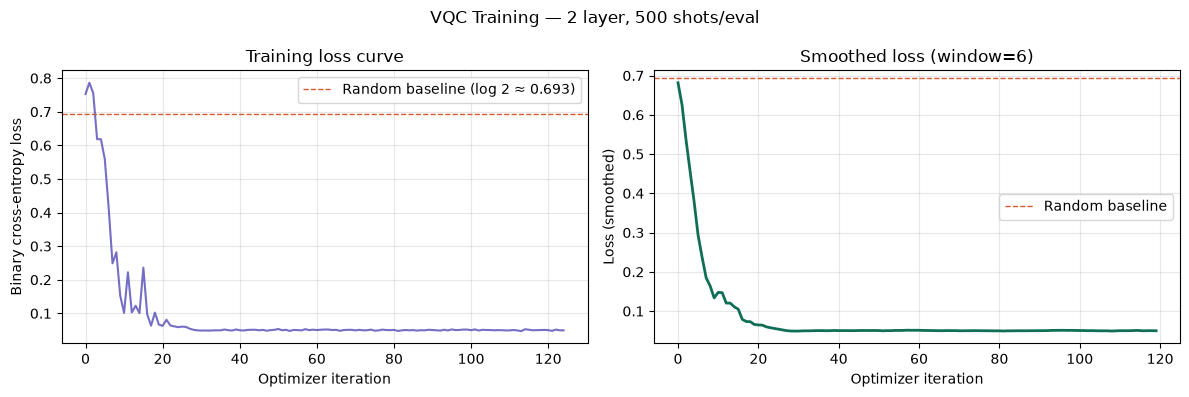

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full loss curve
axes[0].plot(loss_history, color='#534AB7', linewidth=1.5, alpha=0.8)
axes[0].axhline(y=np.log(2), color='#D85A30', linestyle='--',
                linewidth=1, label='Random baseline (log 2 ≈ 0.693)')
axes[0].set_xlabel("Optimizer iteration")
axes[0].set_ylabel("Binary cross-entropy loss")
axes[0].set_title("Training loss curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: smoothed loss (rolling average) to show trend more clearly
window = max(1, len(loss_history) // 20)
smoothed = np.convolve(loss_history, np.ones(window)/window, mode='valid')
axes[1].plot(smoothed, color='#0F6E56', linewidth=2)
axes[1].axhline(y=np.log(2), color='#D85A30', linestyle='--',
                linewidth=1, label='Random baseline')
axes[1].set_xlabel("Optimizer iteration")
axes[1].set_ylabel("Loss (smoothed)")
axes[1].set_title(f"Smoothed loss (window={window})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f"VQC Training — {N_LAYERS} layer, {SHOTS} shots/eval", fontsize=12)
plt.tight_layout()
plt.savefig("../results/loss_curve.png", dpi=150, bbox_inches='tight')
plt.show()

### Evaluating on the Full Test Set

In [22]:
def predict(x, theta_vals, n_layers=1, shots=1000):
    '''
    Returns:
        int(p > 0.5): prediction of the sample's label
            1 if P(|1>) > 0.5, 0 otherwise
        p: int; raw probability number for reference
    '''
    qc, theta = build_vqc(x, n_layers=n_layers)
    p = get_prob(qc, theta, theta_vals, shots)

    return int(p > 0.5), p

In [28]:
# test trained VQC on the full Iris testing dataset
print(f"{'Sample':>8} | {'True label':>10} | {'P(|1>)':>8} | {'Predicted':>10} | {'Correct':>8}")
print("-" * 58)

y_preds = []
y_probs = []
correct = 0

for i in range(len(X_test)):
    y_pred, y_prob = predict(X_test[i], res.x, n_layers=N_LAYERS)
    y_preds.append(y_pred)
    y_probs.append(y_prob)
    is_correct = y_pred == y_test[i]
    correct += is_correct
    print(f"{i:>8} | {y_train[i]:>10} | {y_prob:>8.3f} | {y_pred:>10} | {'✓' if is_correct else '✗':>8}")

print(f"accuracy with optimized parameters: {correct}/{len(X_test)}")

  Sample | True label |   P(|1>) |  Predicted |  Correct
----------------------------------------------------------
       0 |          1 |    0.974 |          1 |        ✓
       1 |          1 |    0.960 |          1 |        ✓
       2 |          0 |    0.882 |          1 |        ✓
       3 |          0 |    0.035 |          0 |        ✓
       4 |          1 |    0.100 |          0 |        ✓
       5 |          0 |    0.010 |          0 |        ✓
       6 |          0 |    0.003 |          0 |        ✓
       7 |          1 |    0.876 |          1 |        ✓
       8 |          0 |    0.009 |          0 |        ✓
       9 |          1 |    0.005 |          0 |        ✓
      10 |          0 |    0.045 |          0 |        ✓
      11 |          0 |    0.017 |          0 |        ✓
      12 |          1 |    0.960 |          1 |        ✓
      13 |          0 |    0.010 |          0 |        ✓
      14 |          1 |    0.947 |          1 |        ✓
      15 |          0 |    0.